   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.4408e+12                                    5.70e+06    
       1              2         4.4608e+10      8.40e+12       3.12e+06       3.79e+05    
       2              3         7.5779e+05      4.46e+10       1.80e+05       1.49e+03    
       3              4         1.4141e+03      7.56e+05       9.43e+02       5.19e-02    
       4              5         1.4141e+03      8.08e-04       2.77e-02       4.08e-06    
       5              6         1.4141e+03      8.99e-09       3.46e-06       1.28e-06    
Both `ftol` and `xtol` termination conditions are satisfied.
Function evaluations 6, initial cost 8.4408e+12, final cost 1.4141e+03, first-order optimality 1.28e-06.


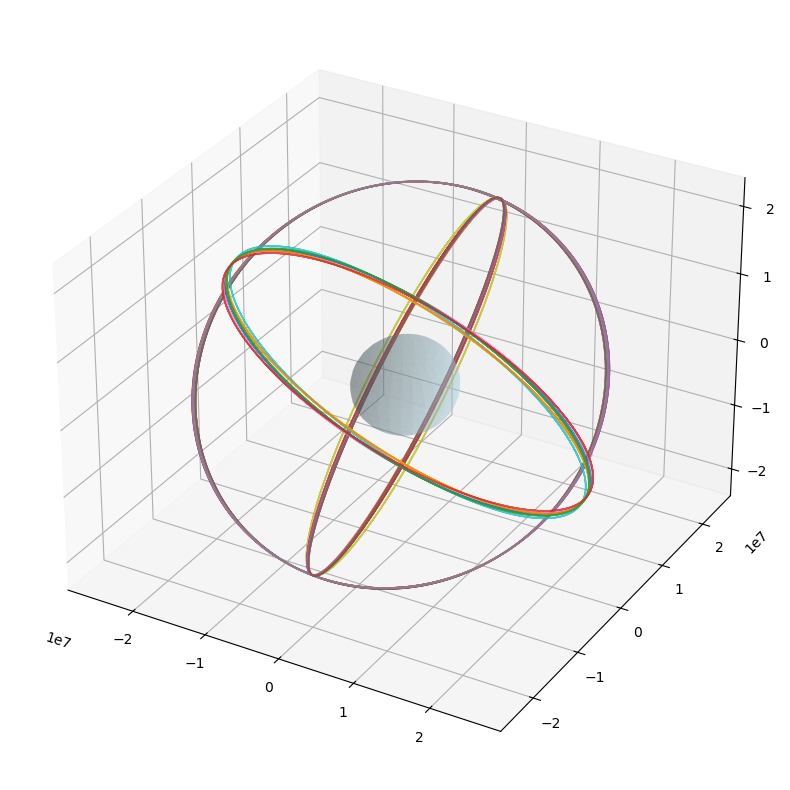

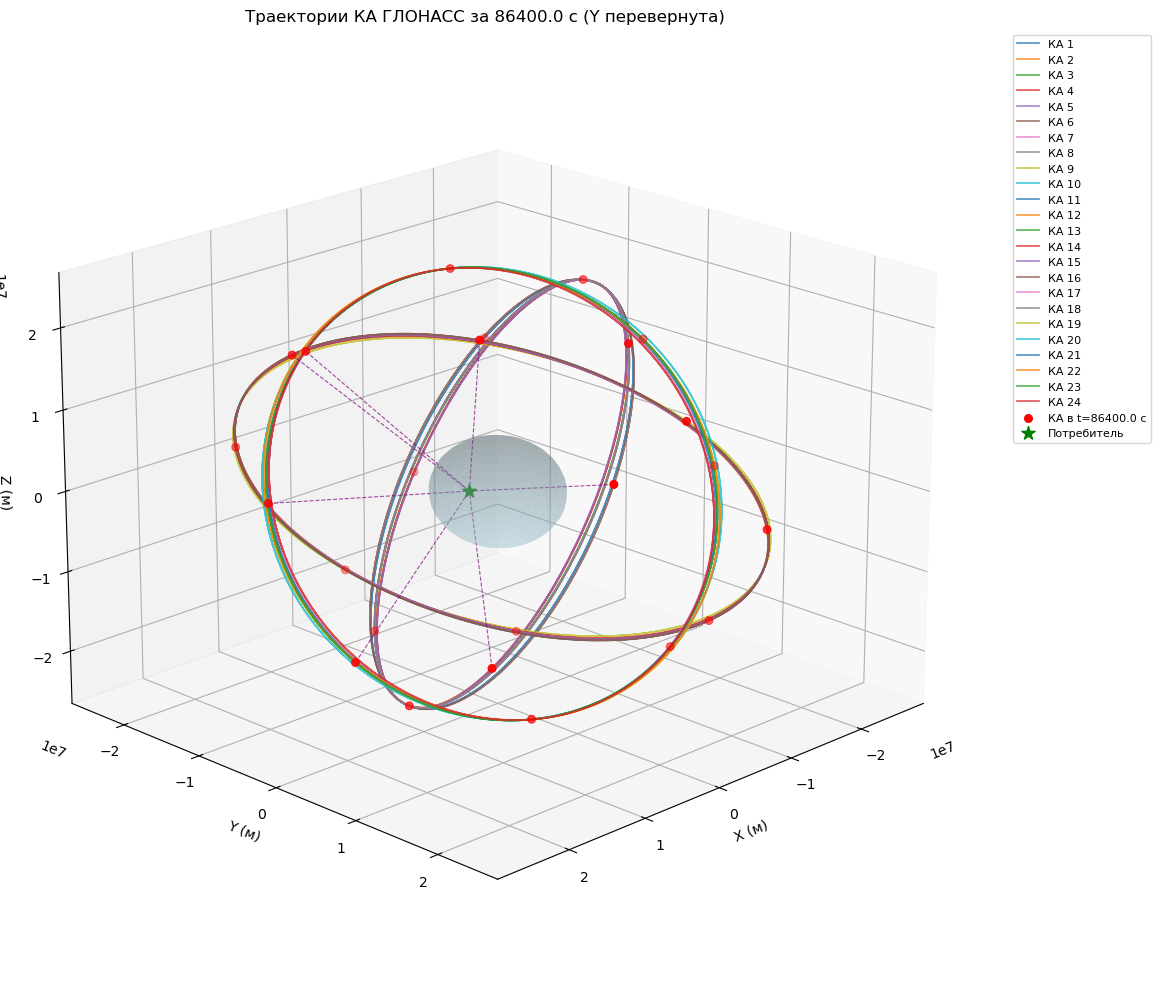

In [ ]:
import numpy as np
import math
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation
from scipy import integrate, optimize

# Константы
MU_M3S2 = 3.986004418E+14
OM_z = 2 * math.pi / (24.0 * 60.0 * 60.0)
R_earth = 6371000  # радиус Земли [м]

# Функция правых частей для интегрирования
def RP(t, LP):
    r = math.sqrt(LP[0]**2 + LP[1]**2 + LP[2]**2)
    x_left = LP[3]
    y_left = LP[4]
    z_left = LP[5]
    Vx_left = -MU_M3S2 * LP[0] / r ** 3
    Vy_left = -MU_M3S2 * LP[1] / r ** 3
    Vz_left = -MU_M3S2 * LP[2] / r ** 3
    return [x_left, y_left, z_left, Vx_left, Vy_left, Vz_left]

# Загрузка эфемерид
ephemeris = np.loadtxt('GLONASS.csv', delimiter=';')
dop_ephemeris = OM_z * ephemeris[:, 0]
RAANs_rad = np.radians(ephemeris[:, 4]) + dop_ephemeris

# Начальные координаты и скорости спутников
xyz_VxVyVz_array = []
for i in range(ephemeris.shape[0]):
    T = ephemeris[i, 1]
    a = math.cbrt(MU_M3S2 * T**2 / (4 * math.pi**2))
    e = ephemeris[i, 2]
    h = math.sqrt(a * MU_M3S2 * (1 - e**2))
    omega_rad = math.radians(ephemeris[i, 5])
    TA_rad = -omega_rad

    # Положение в перефокальной системе
    XYZ = h**2 / (MU_M3S2 * (1 + e * math.cos(TA_rad))) * np.array([math.cos(TA_rad), math.sin(TA_rad), 0.0], dtype=np.float64)
    VxVyVz_perefocal = MU_M3S2 / h * np.array([-math.sin(TA_rad), e + math.cos(TA_rad), 0.0], dtype=np.float64)
    rot_RAAN_Obj = Rotation.from_euler('ZXZ', (RAANs_rad[i], np.radians(ephemeris[i, 3]), omega_rad), degrees=False)
    XYZ_geocentric = rot_RAAN_Obj.apply(XYZ)
    VxVyVz_geocentric = rot_RAAN_Obj.apply(VxVyVz_perefocal)
    row = np.concatenate([XYZ_geocentric, VxVyVz_geocentric])
    xyz_VxVyVz_array.append(row)

xyz_VxVyVz_array = np.array(xyz_VxVyVz_array, dtype=np.float64)
t_k_s = 24.0 * 60.0 * 60.0

# Создание 3D графика
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Сфера Земли
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
x_earth = R_earth * np.cos(u) * np.sin(v)
y_earth = R_earth * np.sin(u) * np.sin(v)
z_earth = R_earth * np.cos(v)
ax.plot_surface(x_earth, -y_earth, z_earth, color='lightblue', alpha=0.3)

# Траектории КА
final_coords = []
for i in range(ephemeris.shape[0]):
    RK4 = integrate.solve_ivp(
        RP,
        [0.0, t_k_s],
        xyz_VxVyVz_array[i],
        method='RK45',
        rtol=1e-10,
        dense_output=True
    )
    final_coords.append(RK4.y[:, -1])
    ax.plot(
        RK4.y[0, :],
        RK4.y[1, :],
        RK4.y[2, :],
        linewidth=1.2,
        alpha=0.8,
        label=f'КА {i+1}'
    )

# Функция для перевода сферических координат в геоцентрические
def sph2geoc(lat_deg, lon_deg, alt_m) -> np.array:
    x = (R_earth + alt_m) * math.cos(math.radians(lat_deg)) * math.cos(math.radians(lon_deg))
    y = (R_earth + alt_m) * math.cos(math.radians(lat_deg)) * math.sin(math.radians(lon_deg))
    z = (R_earth + alt_m) * math.sin(math.radians(lat_deg))
    return np.array([x, y, z])

XYZ_ECEF = sph2geoc(22.121, -41.137, 0.0)

# Учёт вращения Земли
Earth_rotation_ang = OM_z * 5792.3
rotation_matrix = Rotation.from_euler('Z', Earth_rotation_ang, degrees=False).as_matrix()
XYZ_ECI = rotation_matrix @ XYZ_ECEF

# Функция псевдодальности
def pseudorange(t0, tk, XYZ, state0_sc):
    solution = integrate.solve_ivp(RP, [t0, tk], state0_sc, rtol=1e-10, dense_output=True)
    currentXYZ = solution.y[:3, -1]
    visibilityVector = currentXYZ - XYZ
    visibilityCos = np.dot(XYZ, visibilityVector) / (np.linalg.norm(XYZ) * np.linalg.norm(visibilityVector))
    if visibilityCos > math.cos(math.radians(70)):
        return np.linalg.norm(visibilityVector), True
    else:
        return np.linalg.norm(visibilityVector), False

# Вычисление псевдодальностей
pseudoranges = []
for i in range(24):
    initCond = xyz_VxVyVz_array[i, :].astype(np.float64)
    pseudorange_1, isVisible = pseudorange(ephemeris[i, 0], 5792.3, XYZ_ECI, initCond)
    if isVisible:
        pseudorangeNoise = np.random.normal(0.0, 25.0)
        pseudoranges.append(pseudorange_1 + pseudorangeNoise)
    else:
        pseudoranges.append(None)

# Функция вектора невязок
def residual_vector(XYZ_guess, t0_array, tk, ephemeriss, pseudoranges):
    vector_of_residuals = []
    for i in range(24):
        if pseudoranges[i] is None:
            continue
        else:
            calculated_p, isVisisble = pseudorange(t0_array[i], tk, XYZ_guess, ephemeriss[i, :])
            vector_of_residuals.append(pseudoranges[i] - calculated_p)
    return np.array(vector_of_residuals, dtype=np.float64)

new_ephemeris = xyz_VxVyVz_array[:, :]
residual_vector([1000, 1000, 1000], ephemeris[:, 0], 5792.3, new_ephemeris, pseudoranges)

# Определение позиции потребителя методом наименьших квадратов
ls_solution = optimize.least_squares(
    fun=residual_vector,
    x0=[6378e+03, 0.0, 0.0],
    args=(ephemeris[:, 0], 5792.3, new_ephemeris, pseudoranges),
    xtol=1e-10, ftol=1e-10,
    verbose=2
)
ls_solution.x
XYZ_ECI - ls_solution.x
np.linalg.norm(XYZ_ECI - ls_solution.x)

# Создание 3D графика 
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Сфера Земли
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
x_earth = R_earth * np.cos(u) * np.sin(v)
y_earth = R_earth * np.sin(u) * np.sin(v)
z_earth = R_earth * np.cos(v)
ax.plot_surface(x_earth, -y_earth, z_earth, color='lightblue', alpha=0.3)  

# Траектории КА 
final_coords = []
for i in range(ephemeris.shape[0]):
    RK4 = integrate.solve_ivp(
        RP,
        [0.0, t_k_s],
        xyz_VxVyVz_array[i],
        method='RK45',
        rtol=1e-10,
        dense_output=True
    )
    final_coords.append(RK4.y[:, -1])
    ax.plot(
        RK4.y[0, :],   
        -RK4.y[1, :],  
        RK4.y[2, :],   
        linewidth=1.2,
        alpha=0.8,
        label=f'КА {i+1}'
    )

# Позиции КА на момент t_k 
satellite_positions = []
for i in range(ephemeris.shape[0]):
    solution = integrate.solve_ivp(RP, [ephemeris[i, 0], t_k_s], xyz_VxVyVz_array[i], rtol=1e-10, dense_output=True)
    satellite_positions.append(solution.y[:3, -1])
satellite_positions = np.array(satellite_positions)

# Позиция потребителя 
consumer_pos = XYZ_ECI.copy()
consumer_pos[1] = -consumer_pos[1]  
# Видимые спутники
visible_satellites = [i for i in range(len(pseudoranges)) if pseudoranges[i] is not None]

# Отображение КА, потребителя и линий псевдодальностей 
ax.scatter(satellite_positions[:, 0], 
           -satellite_positions[:, 1], 
           satellite_positions[:, 2], 
           color='red', s=30, label=f'КА в t={t_k_s} с', zorder=5)

ax.scatter(consumer_pos[0], consumer_pos[1], consumer_pos[2], 
           color='green', s=100, marker='*', label='Потребитель', zorder=6)

for sat_idx in visible_satellites:
    sat_pos = satellite_positions[sat_idx]
    ax.plot([sat_pos[0], consumer_pos[0]],
            [-sat_pos[1], consumer_pos[1]],  
            [sat_pos[2], consumer_pos[2]],
            color='purple', linewidth=0.8, linestyle='--', alpha=0.7)

# Подписи и настройки осей
ax.set_xlabel('X (м)')
ax.set_ylabel('Y (м)')  
ax.set_zlabel('Z (м)')

ax.set_title(f'Траектории КА ГЛОНАСС за {t_k_s}')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()